## Descripción: Flujo 2D alrededor de un cilindro (Navier–Stokes inverso con pesos adaptativos)

Este ejemplo aborda el flujo incompresible en 2D alrededor de un cilindro dentro de un canal. El objetivo principal no es solo reconstruir el campo $(u,v,p)$ en todo el dominio, sino también resolver un **problema inverso**: **estimar el número de Reynolds** a partir de datos (posiblemente ruidosos) de velocidad y presión.

En esta implementación se utilizan **tres redes neuronales independientes** para aproximar las variables de estado del flujo $(u, v, p)$: `NN_u`, `NN_v` y `NN_p`. El entrenamiento combina dos fuentes de información:

- **Pérdida de datos**: error supervisado sobre mediciones (ruidosas) de $u$, $v$ y $p$.
- **Pérdida física**: residuos de Navier–Stokes (y continuidad) evaluados en puntos de colocación.

La formulación se basa en **Physics-Informed Neural Networks (PINNs)** para Navier–Stokes, siguiendo el enfoque clásico de problemas inversos propuesto por Raissi (2019): además de entrenar los parámetros de la red, se incluye a $Re$ (o su inverso) como **parámetro entrenable** dentro de los residuos físicos del PDE.

Pesos adaptativos (minimax / saddle-point)
El entrenamiento combina múltiples términos de pérdida (datos + física), lo que típicamente introduce **desbalance**: algunos términos dominan el gradiente mientras otros quedan sub-entrenados. Para mitigar esto, este caso incorpora un esquema de **pesado adaptativo** inspirado en el enfoque *Minimax Weighting* discutido por McClenny & Braga-Neto (2020):

- Los **pesos de la red** se actualizan por **descenso de gradiente** (minimización de la pérdida total).
- Los **pesos de los términos de pérdida** (p.ej. $(\lambda_f, \lambda_u, \lambda_v, \lambda_p)$ se actualizan por **ascenso de gradiente**, buscando un **punto silla** (saddle point) en el espacio de pesos.
- Intuitivamente: los términos que **no disminuyen** (o disminuyen poco) tienden a recibir **mayor peso**, lo que empuja al modelo a corregir los componentes “rezagados” del entrenamiento.

> Nota: McClenny & Braga-Neto (2020) introducen *self-adaptive weights* que pueden aplicarse incluso a **puntos individuales** de entrenamiento. En este repositorio se implementa una variante práctica a nivel de **componentes de pérdida**, en línea con esquemas tipo minimax, manteniendo la idea central: ajustar automáticamente la importancia relativa de cada término durante el entrenamiento.

Este ejemplo produce como salidas de la red:
- Reconstrucción del campo completo $(u,v,p)$ en el dominio.
- Estimación del parámetro inverso $\Lambda_{Re} = 1/Re$ (y por lo tanto $Re$).
- Historiales de entrenamiento: pérdidas de datos, pérdidas físicas, evolución de $\lambda$ y evolución de $Re$.  

### Librerias

In [29]:
## Libreriras que deben ser instaladas
from scipy.io import loadmat
from scipy.io import savemat
from scipy import spatial
from sklearn.metrics import mean_squared_error
from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import LBFGS, Adam
from IPython.display import clear_output # lo usamos para que el gráfico se refresque y no te llene la pantalla de miles de gráficos.
import torch.autograd as autograd
import imageio.v2 as imageio
import pandas as pd
import plotly.graph_objects as go
import os
import itertools


## Configura dispositivo GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cpu


### Modelo de Canal 2D con Cilindro Fijo

Este modelo representa un flujo en un canal bidimensional con un cilindro inmerso. Es utilizado para analizar fenómenos de interacción fluido-estructura, formación de estelas, esfuerzos viscosos y dinámica del flujo.

---

Geometría del Canal

- **Dimensiones del canal:** `40 m × 16 m`
- **Cilindro:**
  - Radio: `0.5 m`
  - Ubicación: `x = 0 m`, `y = 0 m`

---

Propiedades del Fluido

- **Densidad (ρ):** `1000 kg/m³`
- **Viscosidad dinámica (μ):** `0.001 Pa·s`
- **Viscosidad cinemática (ν):** `0.01 m²/s`

---

Condiciones Iniciales

- **Velocidad inicial uniforme:** `Uinf = 1 m/s`

---

Condiciones de Borde
- **Entrada del canal (x = -15 m):**  
  Velocidad: `u(-15,y,t) = 1 m/s`
- **Salida del canal (x = 25 m):**  
  Presión: `P(25,y,t) = 0 Pa`
- **Condicion periódica en paredes superior e inferior (y = ±8 m):**  
  Velocidad u: `u(x,8,t)=u(x,-8,t)`
  Velocidad v: `v(x,8,t)=v(x,-8,t)`

---


In [30]:
# ---
## Geometria
Lx = 7  # m
Ly = 4  # m
Dh = 1  # m
# ---
## Parámetros flujo
nu   = 0.01    # m^2/s
Vin  = 1       # m/s
Re   = Dh*Vin/nu
# ---

### Funciones para normalizar y adimenzionalizar datos

In [31]:
def normalizarCampos(tensortonormalize, bounds, eps=1e-12):
    """
    Normaliza 3 canales (x,y,t) o (u,v,p) al rango [-1,1].
    Acepta entrada con shape [..., 3].

    bounds = [max0, min0, max1, min1, max2, min2]
             (ej: [xMax,xMin, yMax,yMin, tMax,tMin] o [uMax,uMin, vMax,vMin, pMax,pMin])
    """
    # Asegurar tensor float32 en el mismo device
    X = tensortonormalize if torch.is_tensor(tensortonormalize) \
        else torch.tensor(tensortonormalize, dtype=torch.float32)
    if X.shape[-1] != 3:
        raise ValueError(f"Última dimensión debe ser 3, recibido {tuple(X.shape)}")

    # Bounds a tensor
    b = bounds if torch.is_tensor(bounds) \
        else torch.tensor(bounds, dtype=torch.float32, device=X.device)
    b = b.to(dtype=torch.float32, device=X.device)

    if b.numel() != 6:
        raise ValueError("bounds debe tener 6 valores: [max0,min0,max1,min1,max2,min2].")

    # Broadcast a [1,1,...,1,3]
    shp = [1] * (X.dim() - 1) + [3]
    max_vals = b[0::2].view(*shp)
    min_vals = b[1::2].view(*shp)

    denom = (max_vals - min_vals).clamp_min(eps)   # evita división por cero
    Xn = 2.0 * (X - min_vals) / denom - 1.0
    return Xn

def desnormalizarCampos(tensor_norm, bounds, eps=1e-12):
    """
    Inversa de normalizarCampos. Acepta shape [..., 3].
    """
    Xn = tensor_norm if torch.is_tensor(tensor_norm) \
        else torch.tensor(tensor_norm, dtype=torch.float32)

    if Xn.shape[-1] != 3:
        raise ValueError(f"Última dimensión debe ser 3, recibido {tuple(Xn.shape)}")

    b = bounds if torch.is_tensor(bounds) \
        else torch.tensor(bounds, dtype=torch.float32, device=Xn.device)
    b = b.to(dtype=torch.float32, device=Xn.device)

    shp = [1] * (Xn.dim() - 1) + [3]
    max_vals = b[0::2].view(*shp)
    min_vals = b[1::2].view(*shp)
    denom = (max_vals - min_vals).clamp_min(eps)

    X = min_vals + 0.5 * (Xn + 1.0) * denom
    return X

def desnorm_last3(self, U_norm, bounds, eps=1e-12):
    """Des-normaliza U_norm con shape [..., 3] usando bounds=[max0,min0,max1,min1,max2,min2]."""
    Un = U_norm if torch.is_tensor(U_norm) else torch.tensor(U_norm, dtype=torch.float32)
    b  = bounds if torch.is_tensor(bounds) else torch.tensor(bounds, dtype=torch.float32, device=Un.device)
    b  = b.to(dtype=torch.float32, device=Un.device)
    # -> shape [1, 1, ..., 1, 3] (mismo nº de dims que U_norm)
    shp = [1] * (Un.dim() - 1) + [3]
    maxv = b[0::2].view(*shp)
    minv = b[1::2].view(*shp)
    denom = (maxv - minv).clamp_min(eps)
    return minv + 0.5 * (Un + 1.0) * denom

In [32]:
def nondim_pack(L: float, Uinf: float, rho: float = 1.0):
    """
    Helpers para (des)adimensionalizar con escalas:
      L0 = L
      U0 = Uinf
      T0 = L/Uinf
      P0 = rho * Uinf^2
    """
    assert L > 0 and Uinf > 0 and rho > 0, "L, Uinf y rho deben ser positivos."

    L0 = float(L)
    U0 = float(Uinf)
    T0 = L0 / U0
    P0 = float(rho) * (U0 ** 2)

    # -------------------------
    # Coordenadas / tiempo
    # -------------------------
    def to_nd_xyt(xyt):
        """
        xyt: array (..., 3) con columnas [x, y, t]
        """
        out = np.array(xyt, dtype=np.float32, copy=True)
        out[..., 0:2] /= L0
        out[..., 2:3] /= T0
        return out

    def to_dim_xyt(xyt_nd):
        out = np.array(xyt_nd, dtype=np.float32, copy=True)
        out[..., 0:2] *= L0
        out[..., 2:3] *= T0
        return out

    # -------------------------
    # Variables geométricas (longitudes)
    # -------------------------
    def to_nd_len(x):
        """Para cualquier variable geométrica con unidades de longitud (m)."""
        return np.array(x, dtype=np.float32, copy=True) / L0

    def to_dim_len(x_nd):
        return np.array(x_nd, dtype=np.float32, copy=True) * L0

    # -------------------------
    # Velocidades y presión
    # -------------------------
    def to_nd_uvp(u=None, v=None, p=None, uvp=None):
        """
        Opciones:
          1) u, v, p como arrays separados
          2) uvp como array (..., 3) con [u, v, p]
        Devuelve: (u_nd, v_nd, p_nd) o array uvp_nd si usás uvp
        """
        if uvp is not None:
            arr = np.array(uvp, dtype=np.float32, copy=True)
            arr[..., 0] /= U0
            arr[..., 1] /= U0
            arr[..., 2] /= P0
            return arr

        if u is None or v is None or p is None:
            raise ValueError("Pasá (u,v,p) o alternativamente uvp.")

        u_nd = np.array(u, dtype=np.float32, copy=True) / U0
        v_nd = np.array(v, dtype=np.float32, copy=True) / U0
        p_nd = np.array(p, dtype=np.float32, copy=True) / P0
        return u_nd, v_nd, p_nd

    def to_dim_uvp(u_nd=None, v_nd=None, p_nd=None, uvp_nd=None):
        """
        Inverso de to_nd_uvp.
        """
        if uvp_nd is not None:
            arr = np.array(uvp_nd, dtype=np.float32, copy=True)
            arr[..., 0] *= U0
            arr[..., 1] *= U0
            arr[..., 2] *= P0
            return arr

        if u_nd is None or v_nd is None or p_nd is None:
            raise ValueError("Pasá (u_nd,v_nd,p_nd) o alternativamente uvp_nd.")

        u = np.array(u_nd, dtype=np.float32, copy=True) * U0
        v = np.array(v_nd, dtype=np.float32, copy=True) * U0
        p = np.array(p_nd, dtype=np.float32, copy=True) * P0
        return u, v, p

    scales = dict(L0=L0, U0=U0, T0=T0, P0=P0, rho=float(rho))
    return to_nd_xyt, to_dim_xyt, to_nd_uvp, to_dim_uvp, to_nd_len, to_dim_len, scales

### Variables y parámetros de la red a modificar

In [33]:
# -----------------------------
# Rearrange Data (subventana)
# -----------------------------
tInit, tEnd = 50, 149
T_sub = tEnd - tInit + 1

# -----------------------------
# Cantidad de puntos de entrenamiento, colocation y test
# -----------------------------
n_data_train = 40
n_colocation = 4000
n_test = 400

# Optimizadores y schedulers seguros para PINNs 2D
n_iter_adam    = 10000
lr_adam        = 1e-2
lr_step_epochs = 5000
lr_gamma       = 0.5  # reduce a la mitad cada 'lr_step_epochs

# LBFGS: desactivar hasta estabilizar con Adam
n_iter_lbfgs   = 1000
lr_LBFGS       = 1e-3

# Lambda learning rate
lr_lambda      = 1e-3

# Estructura de la red y función de inicialización
nneurons = 32
nhiden_layers = 6
activation_fn = nn.Tanh()
make_video = False
input_dim = 3
output_dim =  1
layers_PINN = np.array([input_dim] + [ nneurons for i in range(nhiden_layers)] + [output_dim])

# Flags de entrenamiento
entrenar_lambdas = True  # Si False, las lambdas no se entrenan

seed_id = 1234
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(seed_id)
# Random number generators in other libraries
np.random.seed(seed_id)

print("[INFO] Estructura de la red PINN:")
print(f"  - Capa de entrada: {input_dim} nodos")
print(f"  - Capas ocultas: {nhiden_layers} capas de {nneurons} neuronas cada una")
print(f"  - Capa de salida: {output_dim} nodos")
print(f"  - Arquitectura total: {layers_PINN.tolist()}")


[INFO] Estructura de la red PINN:
  - Capa de entrada: 3 nodos
  - Capas ocultas: 6 capas de 32 neuronas cada una
  - Capa de salida: 1 nodos
  - Arquitectura total: [3, 32, 32, 32, 32, 32, 32, 1]


### Organización y adimensionalización de los datos

En esta sección se preparan los datos de simulación para su análisis,
visualización y posterior uso en el entrenamiento de la PINN. Los datos
originales contienen los campos de velocidad y presión evaluados sobre una
malla espacial fija de N nodos a lo largo de T instantes temporales.

Para trabajar de manera consistente con tensores (y simplificar el muestreo,
la imposición de condiciones iniciales/de borde y la selección de puntos de
colocación), se reordenan las variables en arreglos 3D con forma (T, N, 3).

En particular:
   - Las entradas se almacenan como X ∈ R^{T×N×3}, con componentes (x, y, t).
   - Las salidas/targets se almacenan como U ∈ R^{T×N×3}, con componentes (u, v, p).

Para reducir el costo computacional y focalizar el entrenamiento en una ventana
temporal de interés, se selecciona un subconjunto de instantes definido por los
índices tInit y tEnd, cumpliendo:
   -  0 ≤ tInit ≤ tEnd < T
La longitud del subconjunto temporal es:
   -  T_sub = tEnd - tInit + 1
y se obtienen tensores X y U de tamaño (T_sub, N, 3).

Antes del entrenamiento, tanto las variables geométricas como las variables
físicas se adimensionalizan para mejorar el escalamiento numérico del problema.
Usando escalas características:
   -  L    : escala de longitud
   -  Uinf : escala de velocidad (velocidad de referencia)
   -  rho  : densidad
se definen:
   -  T0 = L / Uinf          (escala temporal)
   -  P0 = rho * Uinf^2      (escala de presión)
y se aplican las transformaciones:
   -  x* = x / L,    y* = y / L,    t* = t / T0
   -  u* = u / Uinf, v* = v / Uinf, p* = p / (rho * Uinf^2)

Finalmente, se generan gráficos instantáneos (scatter) de u, v y p sobre el
plano (x, y) para un instante representativo, como verificación cualitativa
rápida de la consistencia de los datos.

Estructura de datos de simulación (u*, v*, p*): torch.Size([100, 5000, 3])
Tamaño de la malla (x*, y*, t*): torch.Size([100, 5000, 3])
Escalas usadas: {'L': 1, 'Uinf': 1, 'rho': 1.0, 'T0': 1.0, 'P0': 1.0, 'Re': 100.0}


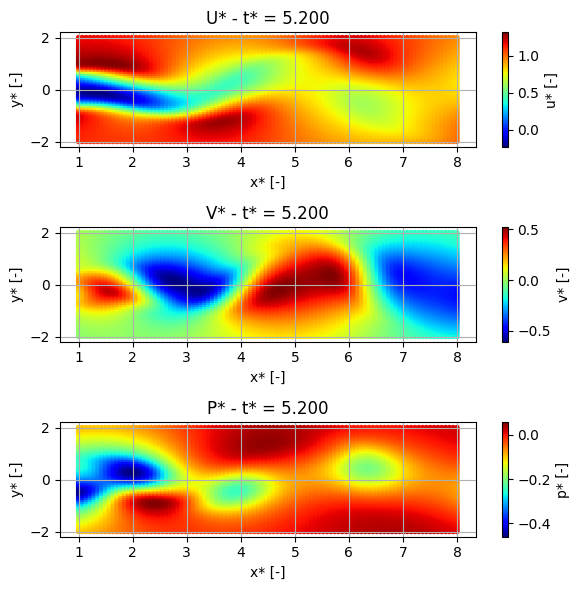

In [34]:
# -----------------------------
# Escalas para adimensionalizar
# -----------------------------
L    = Dh      # L0 (longitud característica)
Uinf = Vin     # U0 (velocidad característica)
rho  = 1.0     # [kg/m^3] si no está definida; si la conocés, reemplazala

T0 = L / Uinf
P0 = rho * Uinf**2

# -----------------------------
# Load Data
# -----------------------------
data = loadmat('./data/cylinder_nektar_wake.mat')
U_star = data['U_star']   # N x 2 x T
P_star = data['p_star']   # N x T
t_star = data['t']        # T x 1
X_star = data['X_star']   # N x 2

N = X_star.shape[0]
T = t_star.shape[0]

# Construcción (dimensional)
x = np.tile(X_star[:, 0:1], (1, T_sub))                 # N x T_sub
y = np.tile(X_star[:, 1:2], (1, T_sub))                 # N x T_sub
t = np.tile(t_star[tInit:tEnd+1], (1, N)).T             # N x T_sub

u = U_star[:, 0, tInit:tEnd+1]                          # N x T_sub
v = U_star[:, 1, tInit:tEnd+1]                          # N x T_sub
p = P_star[:, tInit:tEnd+1]                             # N x T_sub

# -----------------------------
# Adimensionalización
# -----------------------------
x_nd = x / L
y_nd = y / L
t_nd = t / T0

u_nd = u / Uinf
v_nd = v / Uinf
p_nd = p / P0

# Tensores (T_sub, N, 3) adimensionales
Xmesh = np.dstack([x_nd.T, y_nd.T, t_nd.T])             # (T_sub, N, 3) -> (x*, y*, t*)
Xtensor = torch.tensor(Xmesh, dtype=torch.float32, device=device)

Udata = np.dstack([u_nd.T, v_nd.T, p_nd.T])             # (T_sub, N, 3) -> (u*, v*, p*)
Utensor = torch.tensor(Udata, dtype=torch.float32, device=device)

# -----------------------------
# Bounds (sobre variables adimensionales)
# -----------------------------
pMax, pMin = np.max(p_nd), np.min(p_nd)
uMax, uMin = np.max(u_nd), np.min(u_nd)
vMax, vMin = np.max(v_nd), np.min(v_nd)
uNormBound = torch.tensor([uMax, uMin, vMax, vMin, pMax, pMin],
                          dtype=torch.float32, device=device)

xMax, xMin = np.max(x_nd), np.min(x_nd)
yMax, yMin = np.max(y_nd), np.min(y_nd)
tMax, tMin = np.max(t_nd), np.min(t_nd)
xNormBound = [xMax, xMin, yMax, yMin, tMax, tMin]

# -----------------------------
# Visualización (adimensional)
# -----------------------------
tPlot = 2
fig, axs = plt.subplots(3, 1, figsize=(6, 6))

sc1 = axs[0].scatter(Xtensor[tPlot, :, 0].cpu(), Xtensor[tPlot, :, 1].cpu(),
                     c=Utensor[tPlot, :, 0].cpu(), cmap='jet', s=15, edgecolors='none')
plt.colorbar(sc1, ax=axs[0], label='u* [-]')
axs[0].set_title(f'U* - t* = {Xtensor[tPlot,0,2].item():.3f}')
axs[0].set_xlabel('x* [-]')
axs[0].set_ylabel('y* [-]')
axs[0].grid(True)

sc2 = axs[1].scatter(Xtensor[tPlot, :, 0].cpu(), Xtensor[tPlot, :, 1].cpu(),
                     c=Utensor[tPlot, :, 1].cpu(), cmap='jet', s=15, edgecolors='none')
plt.colorbar(sc2, ax=axs[1], label='v* [-]')
axs[1].set_title(f'V* - t* = {Xtensor[tPlot,0,2].item():.3f}')
axs[1].set_xlabel('x* [-]')
axs[1].set_ylabel('y* [-]')
axs[1].grid(True)

sc3 = axs[2].scatter(Xtensor[tPlot, :, 0].cpu(), Xtensor[tPlot, :, 1].cpu(),
                     c=Utensor[tPlot, :, 2].cpu(), cmap='jet', s=15, edgecolors='none')
plt.colorbar(sc3, ax=axs[2], label='p* [-]')
axs[2].set_title(f'P* - t* = {Xtensor[tPlot,0,2].item():.3f}')
axs[2].set_xlabel('x* [-]')
axs[2].set_ylabel('y* [-]')
axs[2].grid(True)

plt.tight_layout()

print("Estructura de datos de simulación (u*, v*, p*):", Utensor.shape)
print("Tamaño de la malla (x*, y*, t*):", Xtensor.shape)
print("Escalas usadas:", {"L": L, "Uinf": Uinf, "rho": rho, "T0": T0, "P0": P0, "Re": Re})

### Creando conjunto de datos de entrenamiento y prueba

Xtensor y Utensor tienen forma (T, N, 3), donde:
  - T: número de instantes temporales,
  - N: número de nodos/puntos espaciales,
  - 3: componentes (x,y,t) en Xtensor y (u,v,p) en Utensor.

La idea es seleccionar *nodos espaciales* (índices en la dimensión N) y usar su evolución completa en el tiempo como:
  - (i)  datos supervisados de entrenamiento (n_data_train),
  - (ii) conjunto de test/validación (n_test),
  - (iii) puntos de colocación para imponer la física (n_colocation).

all_indices = np.arange(Xtensor.shape[1])

Genera el vector [0, 1, ..., N-1], es decir, TODOS los índices posibles de nodos espaciales (la dimensión 1 de Xtensor). A partir de este conjunto total se muestrean, sin reemplazo, los subconjuntos de entrenamiento, test y colocación, asegurando que no se solapen entre sí.

In [35]:
# === Usar función conform_data_matrix (con forma [T, N, 3]) ===
all_indices = np.arange(Xtensor.shape[1])  # asumiendo que mesh es de forma (T,N,3)

# Index selection data
idx_train = np.random.choice(all_indices, n_data_train, replace=False)
idx_available = np.setdiff1d(all_indices, idx_train)  # Remove training set from available data
# Index selection test
idx_test = np.random.choice(idx_available, n_test, replace=False)
idx_available = np.setdiff1d(idx_available, idx_test)  # Remove testing set from available data
# Index selection physics
idx_colocation = np.random.choice(idx_available, n_colocation, replace=False)

# === Selección data para entrenamiento ===
X_datatrain = Xtensor[:,idx_train,:]
U_datatrain = Utensor[:,idx_train,:]

# === Selección puntos de fisica ===
X_collocation = Xtensor[:,idx_colocation,:]

# === Selección data para test ===
X_datatest = Xtensor[:,idx_test,:]
U_datatest = Utensor[:,idx_test,:]

# === Verificación de shapes ===
print("XdataTrain :", X_datatrain.shape, "  UdataTrain:", U_datatrain.shape)
print("Xtest      :", X_datatest.shape, "  Utest      :", U_datatest.shape)
print("Xf         :", X_collocation.shape)

XdataTrain : torch.Size([100, 40, 3])   UdataTrain: torch.Size([100, 40, 3])
Xtest      : torch.Size([100, 400, 3])   Utest      : torch.Size([100, 400, 3])
Xf         : torch.Size([100, 4000, 3])


### Feed-Forward Neural Network

Define la arquitectura y la lógica de una red neuronal multicapas (*Deep Neural Network*) con:

- Capas lineales (`nn.Linear`)
- Función de activación configurable
- Inicialización de pesos con el método de Xavier (*Glorot*)

In [36]:
class DNN(nn.Module):
    def __init__(self, layers, activation_fn=nn.Tanh(), xNormBound=None, normalize_inputs=True):
        """
        layers: lista de tamaños, p.ej. [3, 20, 20, 2]
        activation_fn: nn.Module de activación (por defecto Tanh)
        xNormBound: bounds para normalizar entradas (si normalize_inputs=True)
        normalize_inputs: si True, normaliza x dentro de forward
        """
        super().__init__()
        assert len(layers) >= 2, "Se requieren al menos capa de entrada y de salida"
        self.xNormBound = xNormBound
        self.normalize_inputs = normalize_inputs

        self.activation_fn = activation_fn
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers) - 1)])

        # Xavier init
        for lin in self.linears:
            nn.init.xavier_normal_(lin.weight, gain=1.0)
            nn.init.zeros_(lin.bias)

    def forward(self, x):
        # Normalización opcional de entradas (requiere bounds)
        h = normalizarCampos(x, self.xNormBound) if (self.normalize_inputs and self.xNormBound is not None) else x

        # Capas ocultas con activación
        for layer in self.linears[:-1]:
            h = self.activation_fn(layer(h))

        # Capa de salida sin activación
        out = self.linears[-1](h)
        return out

### Modelo de identifiación - PINNs

In [37]:
class PINN_NavierStokes(nn.Module):
    def __init__(self, layers, Re_init, xNormBound):
        super(PINN_NavierStokes, self).__init__()
        
        self.NN_u = DNN(layers, activation_fn=nn.Tanh(), xNormBound=xNormBound, normalize_inputs=True)
        self.NN_v = DNN(layers, activation_fn=nn.Tanh(), xNormBound=xNormBound, normalize_inputs=True)
        self.NN_p = DNN(layers, activation_fn=nn.Tanh(), xNormBound=xNormBound, normalize_inputs=True)          
        
        self.loss_fn = nn.MSELoss(reduction='mean')
        self.iter = 0
        
        # Reynold init to learning process
        self.Lambda_Re = torch.tensor([float(1.0 / Re_init)], requires_grad=True, device=device)

        # Lambdas como parámetros entrenables
        self.lambda_f  = torch.tensor([float(1)], requires_grad=True, device=device)
        self.lambda_u  = torch.tensor([float(1)], requires_grad=True, device=device)
        self.lambda_v  = torch.tensor([float(1)], requires_grad=True, device=device)
        self.lambda_p  = torch.tensor([float(1)], requires_grad=True, device=device)

        self.loss_history = {
            "Data": [],
            "Physics": [],
            "Lambda": [],
            "Total": [],
            "Reynold": []
        }

    def forward(self, X):
        """Devuelve [u, v, p] en columnas."""
        u = self.NN_u(X)  # (N,1)
        v = self.NN_v(X)  # (N,1)
        p = self.NN_p(X)  # (N,1)
        return torch.cat([u, v, p], dim=-1)  # (N,3)

    def residuals(self, Xf):
        
        Lambda_Re = self.Lambda_Re  # Re calculado en cada iteración
        
        # Xf: [..., 3] en físico (x, y, t)
        X = Xf.clone()  # Este será el X que se deriva
        X.requires_grad = True

        # u, v, p en físico porque forward normaliza internamente
        u = self.NN_u(X)
        v = self.NN_v(X)
        p = self.NN_p(X)

        # Derivadas primeras
        gu = autograd.grad(u, X, grad_outputs=torch.ones_like(u),
                        create_graph=True, retain_graph=True)[0] 
        gv = autograd.grad(v, X, grad_outputs=torch.ones_like(v),
                        create_graph=True, retain_graph=True)[0]
        gp = autograd.grad(p, X, grad_outputs=torch.ones_like(p),
                        create_graph=True, retain_graph=True)[0]

        u_x, u_y, u_t = gu[..., 0:1], gu[..., 1:2], gu[..., 2:3]
        v_x, v_y, v_t = gv[..., 0:1], gv[..., 1:2], gv[..., 2:3]
        p_x, p_y      = gp[..., 0:1], gp[..., 1:2]

        # Derivadas segundas
        u_xx = autograd.grad(u_x, X, grad_outputs=torch.ones_like(u_x),
                            create_graph=True, retain_graph=True)[0][..., 0:1]
        u_yy = autograd.grad(u_y, X, grad_outputs=torch.ones_like(u_y),
                            create_graph=True, retain_graph=True)[0][..., 1:2]
        v_xx = autograd.grad(v_x, X, grad_outputs=torch.ones_like(v_x),
                            create_graph=True, retain_graph=True)[0][..., 0:1]
        v_yy = autograd.grad(v_y, X, grad_outputs=torch.ones_like(v_y),
                            create_graph=True, retain_graph=True)[0][..., 1:2]

        # Residuos (Re físico)
        fx = u_t + (u*u_x + v*u_y) + p_x - Lambda_Re * (u_xx + u_yy)
        fy = v_t + (u*v_x + v*v_y) + p_y - Lambda_Re * (v_xx + v_yy)
        divf = u_x + v_y
        return fx, fy, divf

    def loss_data(self, X, U_real, save=False):
        # Asegurar coherencia device/dtype
        U_real = U_real.to(X.device).to(dtype=X.dtype)

        # Predicciones (red)
        u_pred = self.NN_u(X)
        v_pred = self.NN_v(X) 
        p_pred = self.NN_p(X) 

        # Objetivos (deben estar en el mismo espacio: físico o normalizado según tu pipeline)
        u_true, v_true, p_true = self.split_channels(U_real)  # ...,1

        # Chequeos
        assert u_pred.shape == u_true.shape, f"{u_pred.shape} vs {u_true.shape}"
        assert v_pred.shape == v_true.shape, f"{v_pred.shape} vs {v_true.shape}"
        assert p_pred.shape == p_true.shape, f"{p_pred.shape} vs {p_true.shape}"

        # Pérdida ponderada
        loss_d = (self.lambda_u * self.loss_fn(u_pred, u_true)
                + self.lambda_v * self.loss_fn(v_pred, v_true)
                + self.lambda_p * self.loss_fn(p_pred, p_true))

        if save:
            self.loss_history["Data"].append(loss_d.item())
        return loss_d

    def loss_physics(self, X_phys, save=False):
        fx, fy, divf = self.residuals(X_phys)
        loss_f = self.loss_fn(fx, torch.zeros_like(fx)) + \
                 self.loss_fn(fy, torch.zeros_like(fy)) + \
                 self.loss_fn(divf, torch.zeros_like(divf))
        if save: self.loss_history["Physics"].append(loss_f.item())
        return loss_f

    def loss(self, X_d, U_d, X_colocation, save=False):
        loss_d = self.loss_data(X_d, U_d, save)
        loss_f = self.loss_physics(X_colocation, save)
        #loss_f  = torch.tensor([float(0)], requires_grad=True, device=device)

        loss_total = loss_d + self.lambda_f*loss_f
        if save:
            self.loss_history["Total"].append(loss_total.item())
            self.loss_history["Reynold"].append(self.Lambda_Re.detach().item())
            
        return loss_total, loss_d, loss_f

    def predict(self, X):
        """Devuelve (u,v,p) por separado, cada uno (...,1)."""
        u = self.NN_u(X)
        v = self.NN_v(X)
        p = self.NN_p(X)
        return u, v, p
    
    def split_channels(self, U):
        """
        Acepta U con shape [..., 3] y devuelve (U0, U1, U2) con última dim = 1.
        """
        if U.dim() < 2 or U.shape[-1] != 3:
            raise ValueError(f"Esperaba U con última dim=3, recibido {tuple(U.shape)}")
        return U[..., 0:1], U[..., 1:2], U[..., 2:3]
        
    def evaluate(self, X_eval, U_true, uvp_bounds=None, in_physical=False):
        """
    X_eval : [..., 3]   (mismo escalado que usás en inferencia)
    U_true : [..., 3]   (si in_physical=False -> normalizado; si True -> físico)
    uvp_bounds : [uMax,uMin, vMax,vMin, pMax,pMin] (requerido si in_physical=True)
    in_physical : bool  Si True, calcula RMSE en unidades físicas (desnormaliza pred/true).

    Devuelve:
        u_pred, v_pred, p_pred (mismo espacio que elegiste para RMSE),
        rmse_u, rmse_v, rmse_p
    """
        with torch.no_grad():
            u_pred_n, v_pred_n, p_pred_n = self.predict(X_eval)  # [...,1] cada uno (normalizado según tu pipeline)

            if in_physical:
                # Chequear bounds
                if uvp_bounds is None:
                    # si no pasan, intenta usar los de la instancia
                    if hasattr(self, "u_bounds") and self.u_bounds is not None:
                        uvp_bounds = self.u_bounds
                    else:
                        raise ValueError("Se requieren uvp_bounds para evaluar en unidades físicas.")

                # Predicciones a físico
                U_pred_n = torch.cat([u_pred_n, v_pred_n, p_pred_n], dim=-1)   # [...,3]
                U_pred   = self._desnorm_last3(U_pred_n, uvp_bounds)           # [...,3]
                u_pred, v_pred, p_pred = self.split_channels(U_pred)           # [...,1]

                # Verdadero a físico (si venía normalizado, desnormalizamos; si ya es físico, lo dejamos)
                if U_true.shape[-1] != 3:
                    raise ValueError("U_true debe tener última dimensión = 3")
                # Heurística simple: si su rango está en [-1,1], asumimos normalizado
                u_t, v_t, p_t = self.split_channels(U_true)
                U_true_is_norm = (U_true.max() <= 1.0001) and (U_true.min() >= -1.0001)
                if U_true_is_norm:
                    U_true_phys = self._desnorm_last3(U_true, uvp_bounds)
                else:
                    U_true_phys = U_true
                u_true, v_true, p_true = self.split_channels(U_true_phys)

            else:
                # Evaluación en espacio normalizado
                u_pred, v_pred, p_pred = u_pred_n, v_pred_n, p_pred_n
                u_true, v_true, p_true = self.split_channels(U_true)

            # RMSE
            rmse_u = torch.sqrt(self.loss_fn(u_pred, u_true)).item()
            rmse_v = torch.sqrt(self.loss_fn(v_pred, v_true)).item()
            rmse_p = torch.sqrt(self.loss_fn(p_pred, p_true)).item()

            print(f"Evaluation RMSE  → u: {rmse_u:.4e}, v: {rmse_v:.4e}, p: {rmse_p:.4e}")
        return u_pred, v_pred, p_pred, rmse_u, rmse_v, rmse_p

### Funciones de generación de animaciones

In [38]:
def _to_numpy_1d(arr):
    """Convierte tensores/arrays con shape [...,1] o 1D/2D/3D a un vector 1D."""
    if torch.is_tensor(arr):
        # importante: fuera de grafo y en CPU
        arr = arr.detach().cpu().numpy()
    arr = np.asarray(arr)
    # Casos típicos: (T,N,1) -> TN, (B,1) -> B, (B,) -> B
    if arr.ndim >= 2 and arr.shape[-1] == 1:
        arr = np.squeeze(arr, axis=-1)
    return arr.ravel()

def save_training_animation(model, X_test, U_test, epoch, frames_dir="frames", max_points=None):
    """
    Genera y guarda un frame PNG con u,v,p (pred vs true).
    - Usa inference_mode() para evitar construir grafo.
    - max_points: si se especifica, hace un muestreo uniforme para trazar menos puntos.
    """
    os.makedirs(frames_dir, exist_ok=True)

    # Inferencia sin grafo (más liviano y seguro)
    with torch.inference_mode():
        u_pred, v_pred, p_pred = model.predict(X_test)  # shapes típicas: [...,1]

    # Predicciones a 1D
    u_pred_1d = _to_numpy_1d(u_pred)
    v_pred_1d = _to_numpy_1d(v_pred)
    p_pred_1d = _to_numpy_1d(p_pred)

    # Verdaderos (canales con '...' para última dim = 3)
    if torch.is_tensor(U_test):
        U_np = U_test.detach().cpu().numpy()
    else:
        U_np = np.asarray(U_test)

    u_true_1d = _to_numpy_1d(U_np[..., 0:1])
    v_true_1d = _to_numpy_1d(U_np[..., 1:2])
    p_true_1d = _to_numpy_1d(U_np[..., 2:3])

    # Asegurar mismas longitudes
    L = min(len(u_pred_1d), len(u_true_1d),
            len(v_pred_1d), len(v_true_1d),
            len(p_pred_1d), len(p_true_1d))
    u_pred_1d, u_true_1d = u_pred_1d[:L], u_true_1d[:L]
    v_pred_1d, v_true_1d = v_pred_1d[:L], v_true_1d[:L]
    p_pred_1d, p_true_1d = p_pred_1d[:L], p_true_1d[:L]

    # Submuestreo opcional para trazado (evita arrays gigantes)
    if max_points is not None and L > max_points:
        idx = np.linspace(0, L-1, num=max_points).astype(int)
        u_pred_1d, u_true_1d = u_pred_1d[idx], u_true_1d[idx]
        v_pred_1d, v_true_1d = v_pred_1d[idx], v_true_1d[idx]
        p_pred_1d, p_true_1d = p_pred_1d[idx], p_true_1d[idx]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    axs[0].plot(u_true_1d, label='Simulación u')
    axs[0].plot(u_pred_1d, '--', label='Predicción u')
    axs[0].set_title("Velocidad u"); axs[0].legend(); axs[0].grid(True)

    axs[1].plot(v_true_1d, label='Simulación v')
    axs[1].plot(v_pred_1d, '--', label='Predicción v')
    axs[1].set_title("Velocidad v"); axs[1].legend(); axs[1].grid(True)

    axs[2].plot(p_true_1d, label='Simulación p')
    axs[2].plot(p_pred_1d, '--', label='Predicción p')
    axs[2].set_title("Presión p"); axs[2].legend(); axs[2].grid(True)

    fig.suptitle(f"Epoch {epoch}")
    fname = os.path.join(frames_dir, f"frame_{epoch:06d}.png")
    fig.savefig(fname, dpi=150)
    plt.close(fig)
    return fname

def compile_gif(frames, gif_path="training_animation.gif", duration=0.5, fps=None):
    """
    Crea el GIF en modo streaming (no carga todas las imágenes a la vez).
    - duration: segundos por frame (si fps es None).
    - fps: frames por segundo (opcional; si se da, ignora 'duration').
    """
    frames_sorted = sorted(frames)
    # writer streaming → menos uso de RAM
    if fps is not None:
        writer_kwargs = dict(fps=fps, loop=0)
    else:
        writer_kwargs = dict(duration=duration, loop=0)

    with imageio.get_writer(gif_path, **writer_kwargs) as writer:
        for f in frames_sorted:
            img = imageio.imread(f)  # se libera tras append_data
            writer.append_data(img)
    print(f"GIF guardado en {gif_path}")

def plot_loss_history(model):
    tot = model.loss_history.get('Total', [])
    if len(tot) == 0:
        print('No hay pérdidas todavía')
        return

    epochs = range(len(tot))
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, tot, label='Total Loss')

    data = model.loss_history.get('Data', [])
    phys = model.loss_history.get('Physics', [])
    if len(data) == len(tot):
        plt.plot(epochs, data, label='Data Loss')
    if len(phys) == len(tot):
        plt.plot(epochs, phys, label='Physics Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.legend()
    plt.title('Training Loss Evolution')
    plt.tight_layout()
    plt.show()
    plt.pause(0.001)

def plot_lambdas(model):
    """
    Grafica la evolución de lambda_f, lambda_u, lambda_v, lambda_p
    aunque el historial tenga entradas de distinto largo.
    """
    Lamb = model.loss_history.get("Lambda", [])
    if not Lamb:
        print("Aún no hay lambdas para graficar.")
        return

    rows = []
    for row in Lamb:
        if isinstance(row, (int, float)):
            row = [row]
        elif isinstance(row, dict):
            row = [
                row.get("lambda_f", np.nan),
                row.get("lambda_u", np.nan),
                row.get("lambda_v", np.nan),
                row.get("lambda_p", np.nan),
            ]
        row = list(row)
        if len(row) < 4:
            row = row + [np.nan] * (4 - len(row))
        elif len(row) > 4:
            row = row[:4]
        rows.append(row)

    Lamb_arr = np.asarray(rows, dtype=float)  # [E,4]
    epochs = np.arange(Lamb_arr.shape[0])

    plt.figure(figsize=(8,5))
    names = ["lambda_f", "lambda_u", "lambda_v", "lambda_p"]
    for i, name in enumerate(names):
        series = Lamb_arr[:, i]
        if np.all(np.isnan(series)):
            continue
        plt.plot(epochs, series, label=name)

    plt.yscale('log')  # opcional
    plt.xlabel("Epoch (registro)")
    plt.ylabel("Valor lambda")
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.legend()
    plt.title("Evolución de lambdas")
    plt.tight_layout()
    plt.show()
    plt.pause(0.001)

def plot_reynolds(model, Re_true=None, mode="lambda"):
    """
    mode = "lambda"  → grafica λ_Re = 1/Re aprendido (y opcionalmente 1/Re_true)
    mode = "Re"      → grafica Re_est = 1/λ_Re (y opcionalmente Re_true)
    """
    hist = model.loss_history.get("Reynold", [])
    if not hist:
        print("Aún no hay registros en loss_history['Reynold'].")
        return

    lam_hist = np.asarray(hist, dtype=float)  # λ_Re(k)
    epochs   = np.arange(len(lam_hist))

    plt.figure(figsize=(8,5))
    if mode == "lambda":
        plt.plot(epochs, lam_hist, label=r"$\lambda_{Re}$ (aprendido)")
        if Re_true is not None:
            plt.hlines(1.0/float(Re_true), 0, len(epochs)-1,
                       linestyles="--", label=r"$1/Re$ (verdadero)")
        plt.ylabel(r"$\lambda_{Re} = 1/Re$")
        plt.title("Evolución de $\lambda_{Re}$")
    elif mode == "Re":
        eps = 1e-12
        Re_est = 1.0 / np.clip(lam_hist, eps, None)
        plt.plot(epochs, Re_est, label=r"$Re$ (estimado)")
        if Re_true is not None:
            plt.hlines(float(Re_true), 0, len(epochs)-1,
                       linestyles="--", label=r"$Re$ (verdadero)")
        plt.ylabel(r"$Re$")
        plt.title("Evolución de $Re$")
    else:
        raise ValueError("mode debe ser 'lambda' o 'Re'.")

    plt.xlabel("Epoch (registro)")
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.pause(0.001)

<>:189: SyntaxWarning: invalid escape sequence '\l'
<>:189: SyntaxWarning: invalid escape sequence '\l'
C:\Users\scorrea\AppData\Local\Temp\ipykernel_16248\1155547522.py:189: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Evolución de $\lambda_{Re}$")


### Entrenar modelo

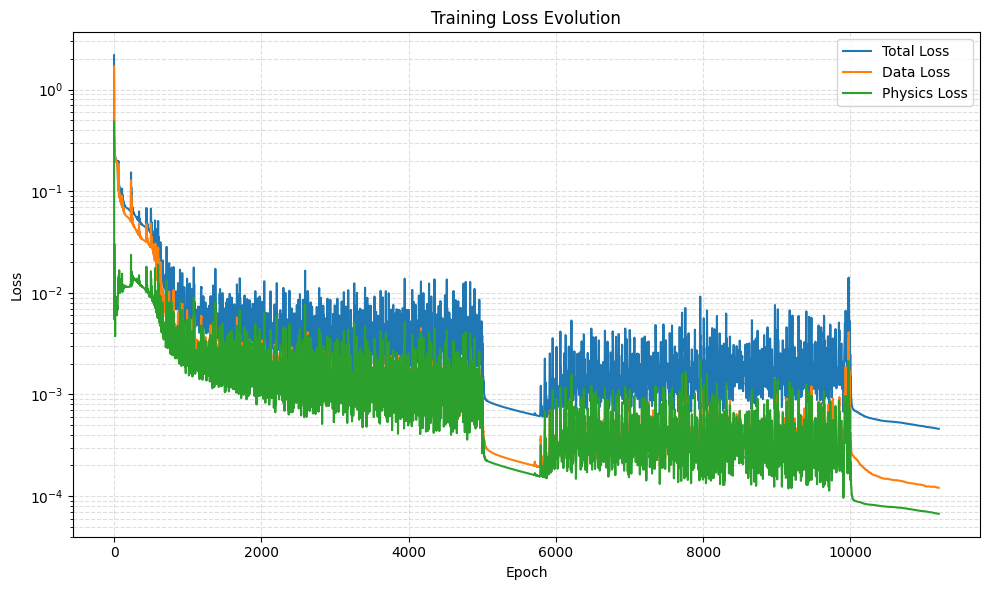

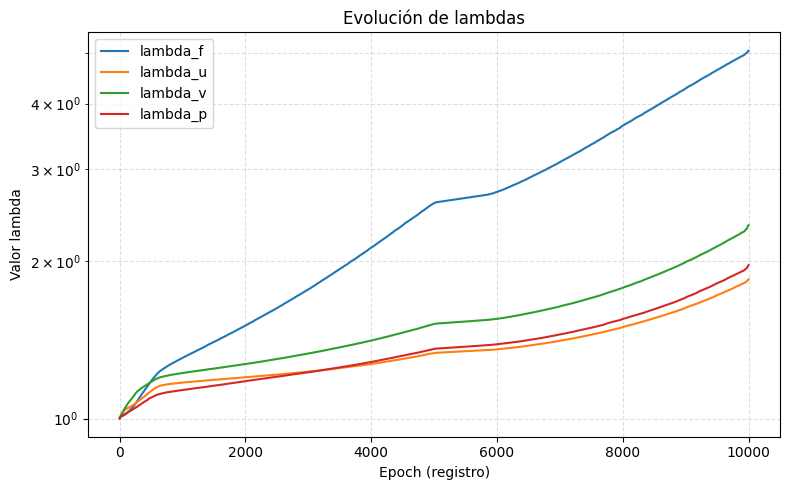

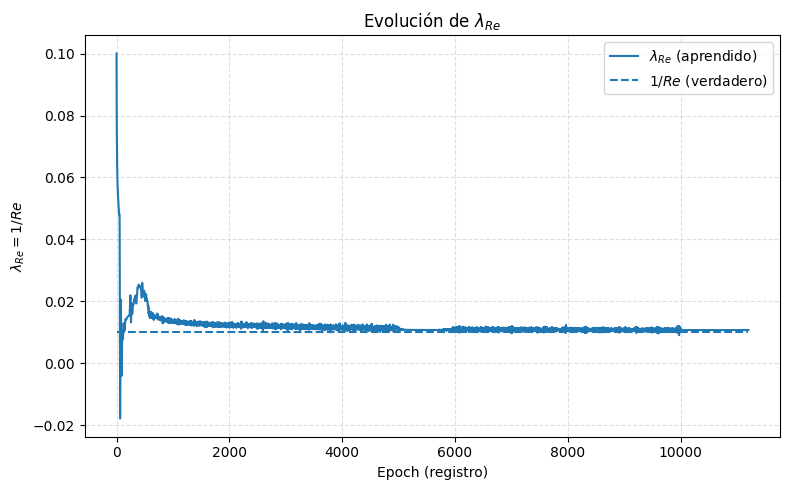

[Epoch ADAM 11200] Total: 4.5893e-04 | Data: 1.2086e-04 | Physics: 6.6947e-05 | Re_pred/Re_real = 93.302 / 100.000 | lambda_Re = 1.0718e-02


tensor([0.0015], grad_fn=<AddBackward0>)

In [39]:
def model_param_groups(m):
    params = list(itertools.chain(
        m.NN_u.parameters(),
        m.NN_v.parameters(),
        m.NN_p.parameters(),
    ))
    return params

# === First guess for Reynolds number ===
Re_init = 10.0  # Reynolds inicial (puede estar lejos del real)
# === Inicialización del modelo y optimizadores ===
model = PINN_NavierStokes(layers=layers_PINN, Re_init=Re_init, xNormBound=xNormBound)
model = model.to(device)
print('Training NN')

optimizer_model  = torch.optim.Adam(model_param_groups(model), lr=lr_adam)
scheduler_model  = torch.optim.lr_scheduler.StepLR(optimizer_model,  step_size=lr_step_epochs, gamma=lr_gamma)

optimizer_re = torch.optim.Adam([model.Lambda_Re], lr=lr_adam)  

params_lambda = [model.lambda_f, model.lambda_u, model.lambda_v, model.lambda_p]
optimizer_lambda = torch.optim.Adam(params_lambda, lr=lr_lambda)

# === Entrenamiento con ADAM ===
for epoch in range(n_iter_adam):
    optimizer_model.zero_grad()
    optimizer_re.zero_grad()
    if entrenar_lambdas:
        optimizer_lambda.zero_grad()

    loss_total, loss_d, loss_physics = model.loss(
        X_datatrain, U_datatrain,
        X_collocation, 
        save=True)

    loss_total.backward()

    # Inversión del gradiente si no estás usando balance adversarial
    if entrenar_lambdas:  
        for p in params_lambda:
            if p.grad is not None:
                p.grad *= -1.0

    optimizer_model.step()
    optimizer_re.step()
    if entrenar_lambdas:
        optimizer_lambda.step()
    
    scheduler_model.step()

    model.loss_history["Lambda"].append([
    float(model.lambda_f.item()),
    float(model.lambda_u.item()),
    float(model.lambda_v.item()),
    float(model.lambda_p.item()),
    ])

    if epoch % 100 == 0:
        clear_output(wait=True)
        plot_loss_history(model)
        plot_lambdas(model)
        plot_reynolds(model, Re_true=Re, mode="lambda")
        print(
        f"[Epoch LBFGS {len(model.loss_history['Total']):04d}] "
        f"Total: {loss_total.item():.4e} | Data: {loss_d.item():.4e} | Physics: {loss_physics.item():.4e} | "
        f"Re_pred/Re_real = {1.0 / max(float(model.Lambda_Re.detach().item()), 1e-12):.3f} / {float(Re):.3f} | "
        f"lambda_Re = {float(model.Lambda_Re.detach().item()):.4e}"
        )

# === Optimización final con LBFGS ===
params_all = model.parameters()
optimizer_lbfgs = torch.optim.LBFGS(
    params_all, lr=lr_LBFGS, 
    max_iter=n_iter_lbfgs,
    max_eval = None, 
    tolerance_grad = 1e-11, 
    tolerance_change = 1e-11, 
    line_search_fn = 'strong_wolfe',
    history_size = 100)

def closure():
    optimizer_lbfgs.zero_grad()
    loss_total, loss_d, loss_physics = model.loss(
        X_datatrain, U_datatrain,
        X_collocation, 
        save=True
    ) # 
    
    loss_total.backward()

    if len(model.loss_history["Total"]) % 100 == 0:
        clear_output(wait=True)
        plot_loss_history(model)
        plot_lambdas(model)
        plot_reynolds(model, Re_true=Re, mode="lambda")
        print(
        f"[Epoch ADAM {len(model.loss_history['Total']):04d}] "
        f"Total: {loss_total.item():.4e} | Data: {loss_d.item():.4e} | Physics: {loss_physics.item():.4e} | "
        f"Re_pred/Re_real = {1.0 / max(float(model.Lambda_Re.detach().item()), 1e-12):.3f} / {float(Re):.3f} | "
        f"lambda_Re = {float(model.Lambda_Re.detach().item()):.4e}"
        )

    return loss_total

print("Continuando con LBFGS...")
optimizer_lbfgs.step(closure)



RMSE   → u: 1.8010e-02, v: 1.0816e-02, p: 6.4004e-03
RelRMSE→ u: 2.09%, v: 4.69%, p: 6.94%


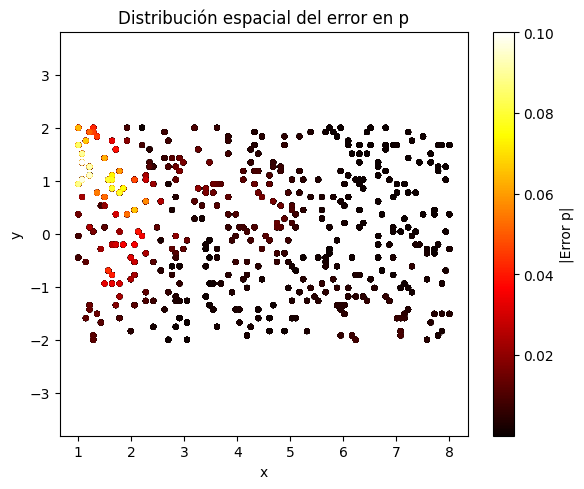

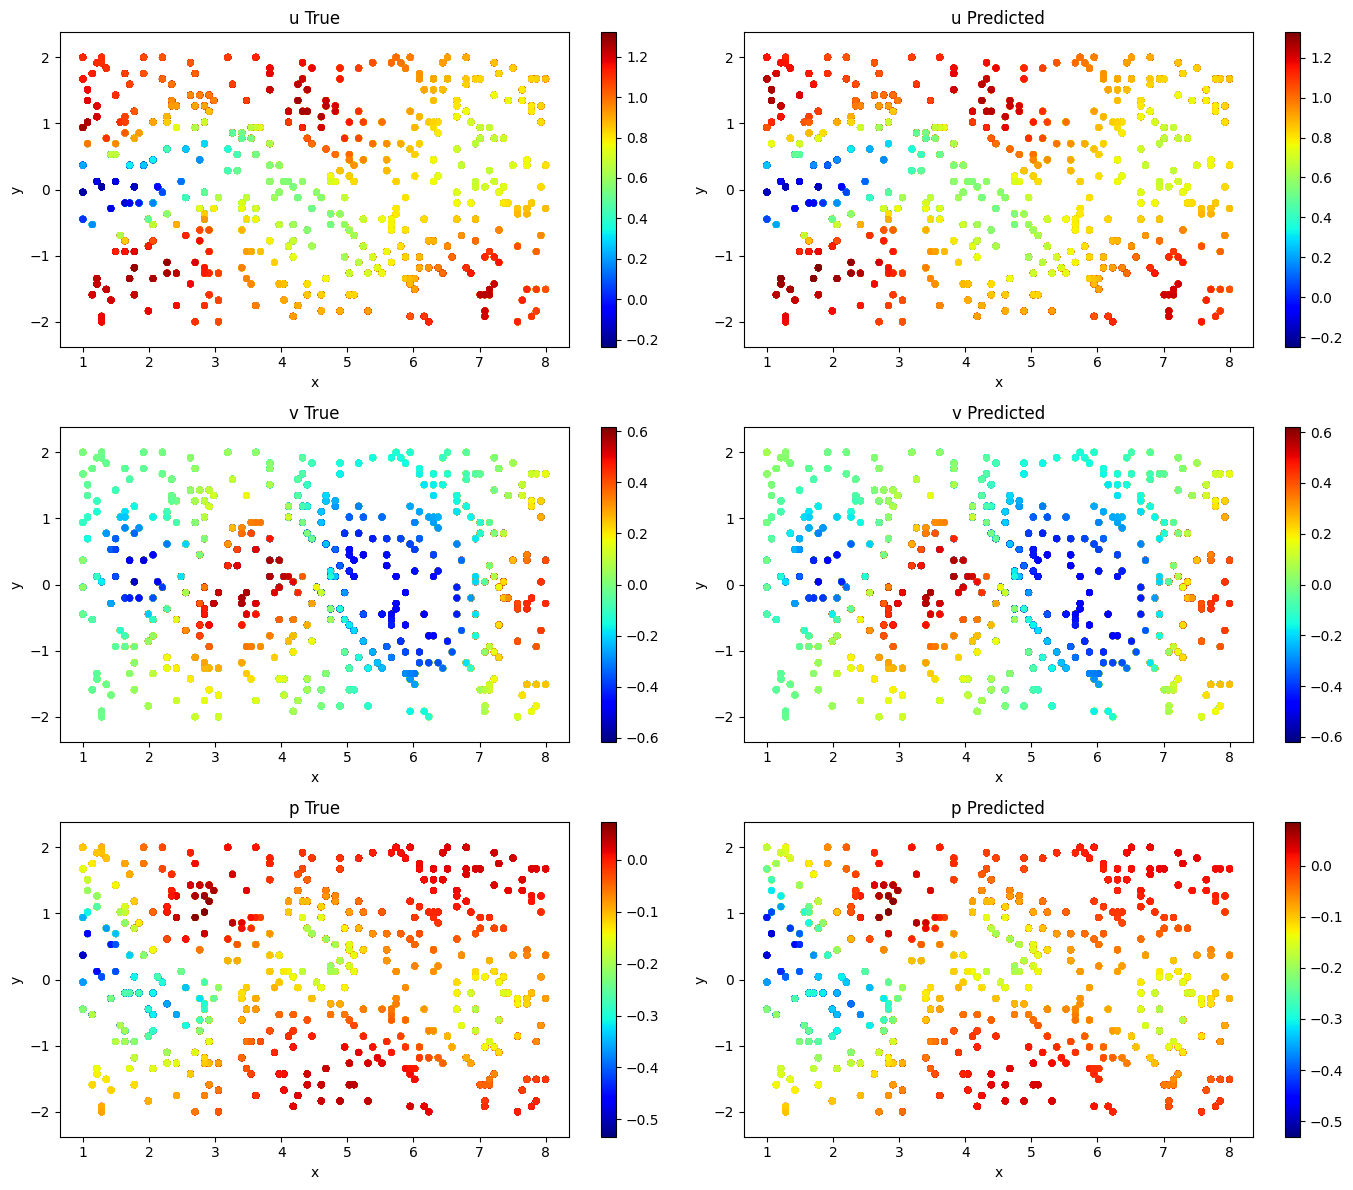

In [40]:
def _to_numpy_1d(x):
    """Convierte tensor/array con shape [...,1] o [...,C] a 1D."""
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    # si es [...,1] -> quitar última dim
    if x.ndim >= 2 and x.shape[-1] == 1:
        x = np.squeeze(x, axis=-1)
    return x.ravel()

def _split_last3(U):
    """Separa canales de U con shape [...,3] -> (u,v,p) como 1D."""
    if torch.is_tensor(U):
        U = U.detach().cpu().numpy()
    U = np.asarray(U)
    assert U.shape[-1] == 3, f"Última dim debe ser 3, recibido {U.shape}"
    u = U[..., 0].ravel()
    v = U[..., 1].ravel()
    p = U[..., 2].ravel()
    return u, v, p

# ---- Predicción ----
u_pred_t = model.NN_u(X_datatest)
v_pred_t = model.NN_v(X_datatest)
p_pred_t = model.NN_p(X_datatest)

# ---- A numpy 1D ----
u_pred = _to_numpy_1d(u_pred_t)
v_pred = _to_numpy_1d(v_pred_t)
p_pred = _to_numpy_1d(p_pred_t)

# ---- Verdaderos (última dim = 3) ----
u_true, v_true, p_true = _split_last3(U_datatest)

# Alinear longitudes por si hay pequeñas desincronizaciones
L = min(len(u_pred), len(u_true), len(v_pred), len(v_true), len(p_pred), len(p_true))

u_pred, u_true = u_pred[:L], u_true[:L]
v_pred, v_true = v_pred[:L], v_true[:L]
p_pred, p_true = p_pred[:L], p_true[:L]

# ---- Métricas ----
mse_u = mean_squared_error(u_true, u_pred)
mse_v = mean_squared_error(v_true, v_pred)
mse_p = mean_squared_error(p_true, p_pred)

rmse_u = np.sqrt(mse_u)
rmse_v = np.sqrt(mse_v)
rmse_p = np.sqrt(mse_p)

eps = 1e-12
rel_u = rmse_u / (np.mean(np.abs(u_true)) + eps)
rel_v = rmse_v / (np.mean(np.abs(v_true)) + eps)
rel_p = rmse_p / (np.mean(np.abs(p_true)) + eps)

print(f"RMSE   → u: {rmse_u:.4e}, v: {rmse_v:.4e}, p: {rmse_p:.4e}")
print(f"RelRMSE→ u: {rel_u:.2%}, v: {rel_v:.2%}, p: {rel_p:.2%}")

# ---- Coordenadas para plots ----
# X_datatest puede ser [...,3]; tomamos x,y y los aplanamos a 1D
if torch.is_tensor(X_datatest):
    X_np = X_datatest.detach().cpu().numpy()
else:
    X_np = np.asarray(X_datatest)
x_all = X_np[..., 0].ravel()[:L]
y_all = X_np[..., 1].ravel()[:L]

# ---- Mapas de error (ej: presión) ----
plt.figure(figsize=(6, 5))
plt.scatter(x_all, y_all, c=np.abs(p_true - p_pred), cmap='hot', s=10)
plt.colorbar(label='|Error p|')
plt.title('Distribución espacial del error en p')
plt.xlabel('x'); plt.ylabel('y'); plt.axis('equal'); plt.tight_layout()
plt.show()

# ---- Comparativas true vs pred ----
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

sc = axs[0, 0].scatter(x_all, y_all, c=u_true, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[0, 0]); axs[0, 0].set_title('u True')

sc = axs[0, 1].scatter(x_all, y_all, c=u_pred, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[0, 1]); axs[0, 1].set_title('u Predicted')

sc = axs[1, 0].scatter(x_all, y_all, c=v_true, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[1, 0]); axs[1, 0].set_title('v True')

sc = axs[1, 1].scatter(x_all, y_all, c=v_pred, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[1, 1]); axs[1, 1].set_title('v Predicted')

sc = axs[2, 0].scatter(x_all, y_all, c=p_true, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[2, 0]); axs[2, 0].set_title('p True')

sc = axs[2, 1].scatter(x_all, y_all, c=p_pred, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[2, 1]); axs[2, 1].set_title('p Predicted')

for ax in axs.flatten():
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.axis('equal')
plt.tight_layout(); plt.show()

### PostProcessing

[t = 5.9000] RMSE   → u: 1.8906e-02, v: 1.4694e-02, p: 4.0058e-03
[t = 5.9000] RelRMSE→ u: 2.19%, v: 6.58%, p: 4.36%


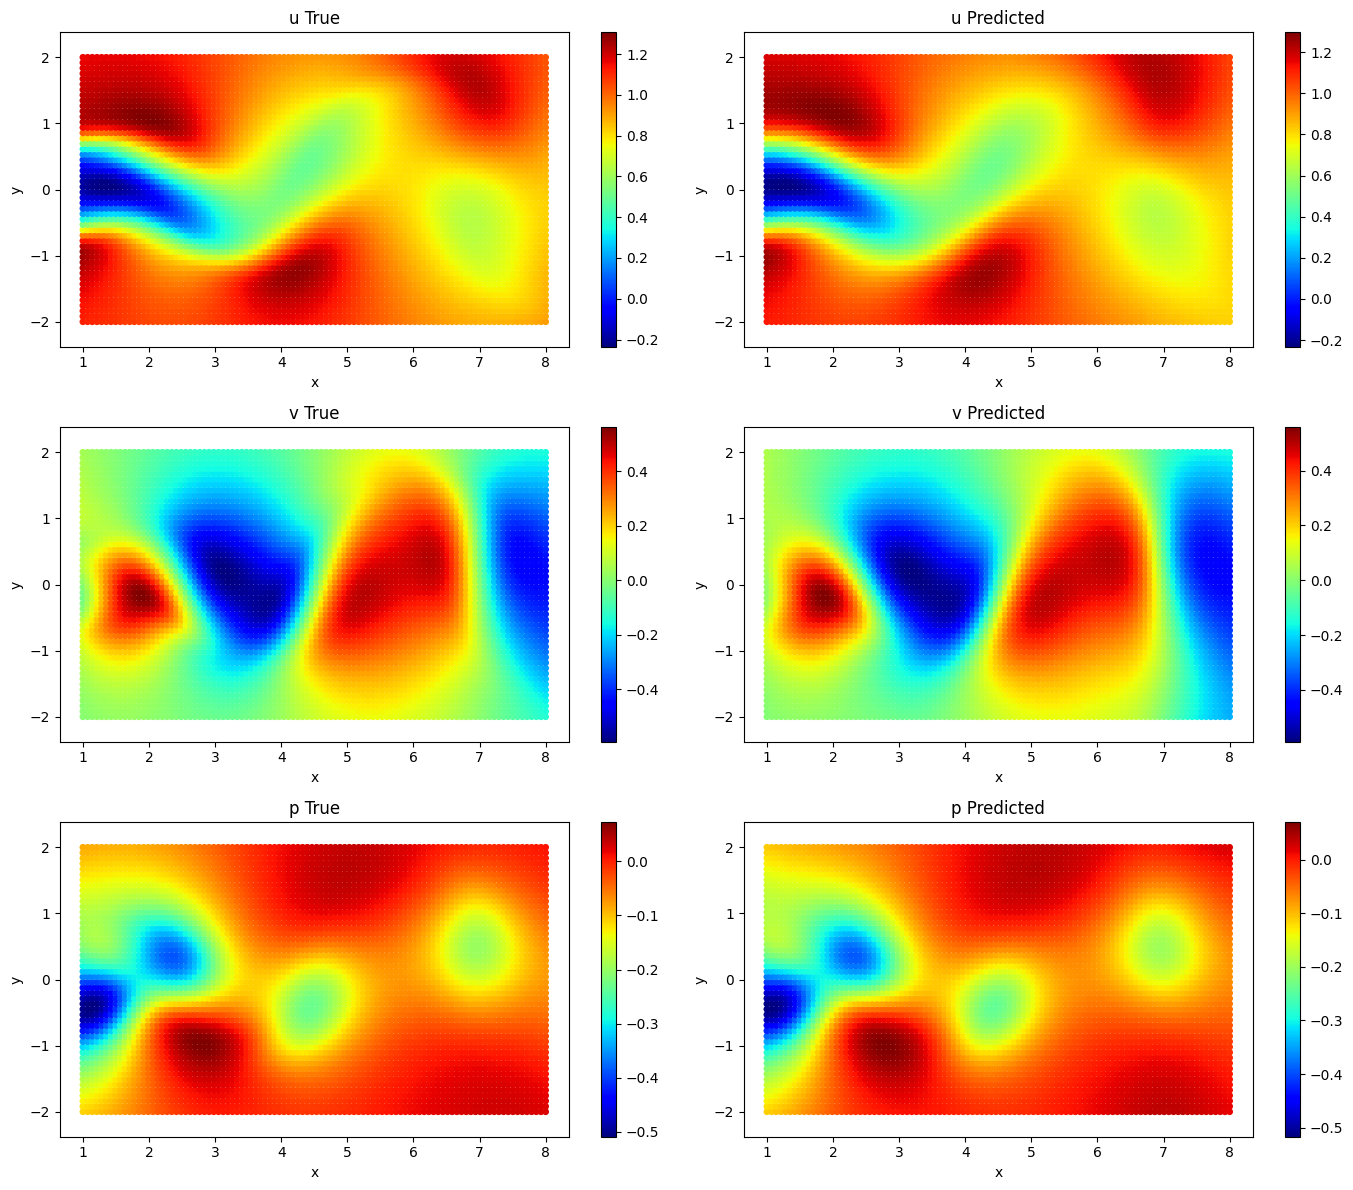

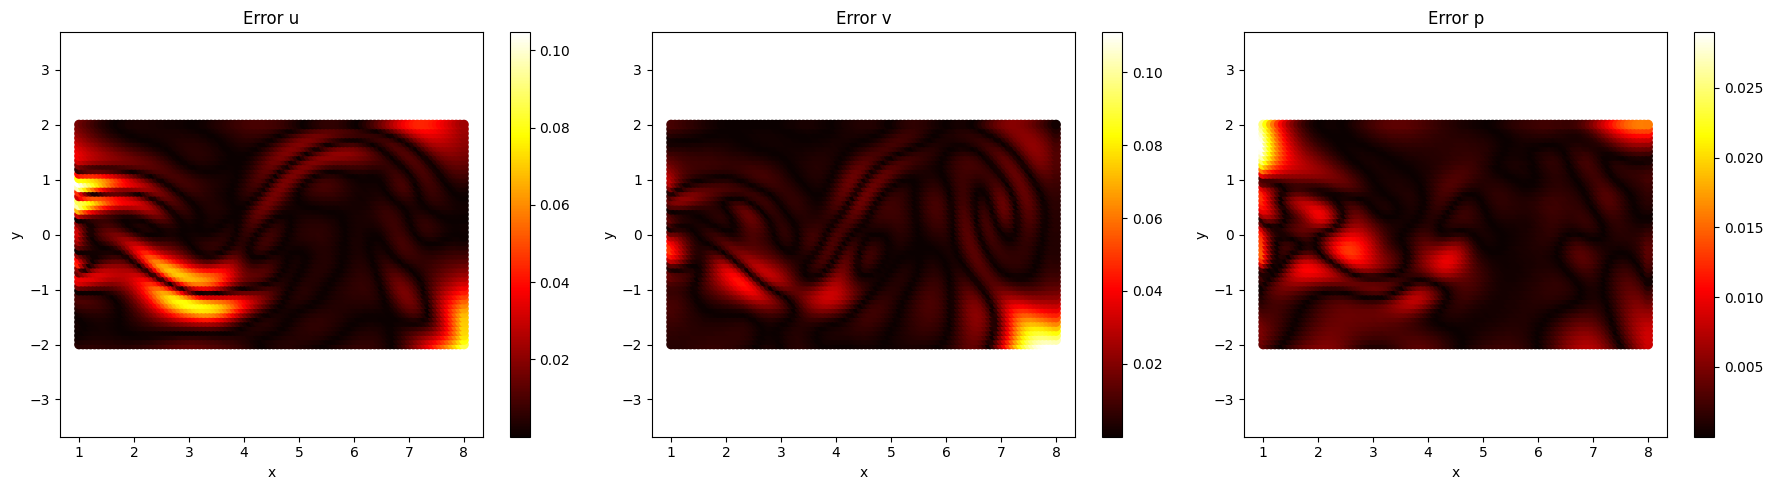

[DEBUG] Pred shapes: torch.Size([1, 5000, 1]) torch.Size([1, 5000, 1]) torch.Size([1, 5000, 1])
[DEBUG] True shapes: torch.Size([5000, 3])  (esperado (N,3))


In [45]:
def _vec(a):
    """numpy 1D vector (exprime última dim si es [...,1])."""
    a = a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)
    if a.ndim >= 2 and a.shape[-1] == 1:
        a = np.squeeze(a, axis=-1)
    return a.ravel()

def _vec3(U):
    """Separa U en (u,v,p) como 1D, soporta [N,3,T] o [T,N,3] o [...,3]."""
    U = U.detach().cpu().numpy() if torch.is_tensor(U) else np.asarray(U)
    if U.ndim == 3 and U.shape[1] == 3:
        # [N, 3, T] → devolver función que indexa por tloc
        def at_t(tloc):
            return U[:, 0, tloc].ravel(), U[:, 1, tloc].ravel(), U[:, 2, tloc].ravel()
        return at_t
    elif U.ndim == 3 and U.shape[2] == 3:
        # [T, N, 3]
        def at_t(tloc):
            return U[tloc, :, 0].ravel(), U[tloc, :, 1].ravel(), U[tloc, :, 2].ravel()
        return at_t
    elif U.ndim >= 2 and U.shape[-1] == 3:
        # [..., 3] sin eje temporal
        def at_t(_):
            return U[..., 0].ravel(), U[..., 1].ravel(), U[..., 2].ravel()
        return at_t
    else:
        raise ValueError(f"Formato de U no reconocido: {U.shape}")

def _scalar_time(tf, tloc):
    """Devuelve escalar float del tiempo en el índice tloc (tf puede ser [T], [T,1], [1,T])."""
    tf = tf.detach().cpu().numpy() if torch.is_tensor(tf) else np.asarray(tf)
    val = tf[tloc]
    return float(val) if np.ndim(val) == 0 else float(np.asarray(val).squeeze())

def plot_results(x, y, u_true, v_true, p_true, u_pred, v_pred, p_pred):
    x = _vec(x); y = _vec(y)
    u_true = _vec(u_true); v_true = _vec(v_true); p_true = _vec(p_true)
    u_pred = _vec(u_pred); v_pred = _vec(v_pred); p_pred = _vec(p_pred)

    # Alinear longitudes
    L = min(len(x), len(y), len(u_true), len(v_true), len(p_true),
            len(u_pred), len(v_pred), len(p_pred))
    x, y = x[:L], y[:L]
    u_true, v_true, p_true = u_true[:L], v_true[:L], p_true[:L]
    u_pred, v_pred, p_pred = u_pred[:L], v_pred[:L], p_pred[:L]

    fig, axs = plt.subplots(3, 2, figsize=(14, 12))

    sc = axs[0, 0].scatter(x, y, c=u_true, cmap='jet', s=15)
    plt.colorbar(sc, ax=axs[0, 0]); axs[0, 0].set_title('u True')

    sc = axs[0, 1].scatter(x, y, c=u_pred, cmap='jet', s=15)
    plt.colorbar(sc, ax=axs[0, 1]); axs[0, 1].set_title('u Predicted')

    sc = axs[1, 0].scatter(x, y, c=v_true, cmap='jet', s=15)
    plt.colorbar(sc, ax=axs[1, 0]); axs[1, 0].set_title('v True')

    sc = axs[1, 1].scatter(x, y, c=v_pred, cmap='jet', s=15)
    plt.colorbar(sc, ax=axs[1, 1]); axs[1, 1].set_title('v Predicted')

    sc = axs[2, 0].scatter(x, y, c=p_true, cmap='jet', s=15)
    plt.colorbar(sc, ax=axs[2, 0]); axs[2, 0].set_title('p True')

    sc = axs[2, 1].scatter(x, y, c=p_pred, cmap='jet', s=15)
    plt.colorbar(sc, ax=axs[2, 1]); axs[2, 1].set_title('p Predicted')

    for ax in axs.flatten():
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.axis('equal')

    plt.tight_layout(); plt.show()

    # Errores
    err_u = np.abs(u_true - u_pred)
    err_v = np.abs(v_true - v_pred)
    err_p = np.abs(p_true - p_pred)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    sc = axs[0].scatter(x, y, c=err_u, cmap='hot')
    plt.colorbar(sc, ax=axs[0]); axs[0].set_title('Error u')

    sc = axs[1].scatter(x, y, c=err_v, cmap='hot')
    plt.colorbar(sc, ax=axs[1]); axs[1].set_title('Error v')

    sc = axs[2].scatter(x, y, c=err_p, cmap='hot')
    plt.colorbar(sc, ax=axs[2]); axs[2].set_title('Error p')

    for ax in axs:
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.axis('equal')

    plt.tight_layout(); plt.show()
    
# ---- Plots finales ----

# === Paso 1: elegir frame temporal ===
k = 9  # por ejemplo
T_sub = Xtensor.shape[0]
assert 0 <= k < T_sub, f"k fuera de rango: 0 <= k < {T_sub}"

# Tiempo del frame k (opcional, por si querés mostrarlo)
tmodel = float(Xtensor[k, 0, 2].item())

# === Paso 2: entrada al modelo: directamente el frame k ===
# Xtensor es (T_sub, N, 3) → tomamos (N,3)
X_model_tensor = Xtensor[k, :, :].unsqueeze(0).to(device)  # (1, N, 3)
# === Paso 3: predicción ===
out =  model.predict(X_model_tensor)
# Caso 1: predict devuelve tupla/lista
if isinstance(out, (tuple, list)):
    if len(out) == 3:
        # (u, v, p)
        u_pred, v_pred, p_pred = out
    else:
        # (pred, algo_mas, ...)
        out0 = out[0]
        # si out0 es pred con 3 canales al final: [...,3]
        if (torch.is_tensor(out0) or isinstance(out0, np.ndarray)) and out0.shape[-1] == 3:
            u_pred = out0[..., 0]
            v_pred = out0[..., 1]
            p_pred = out0[..., 2]
        else:
            raise TypeError(f"model.predict devolvió tuple/list con formato no soportado. "
                            f"len={len(out)}, type(out[0])={type(out0)}, shape(getattr(out0,'shape',None))={getattr(out0,'shape',None)}")
else:
    # Caso 2: predict devuelve tensor/ndarray con 3 canales al final
    if out.shape[-1] != 3:
        raise ValueError(f"Se esperaba salida con última dimensión = 3, pero llegó {out.shape}")
    u_pred = out[..., 0]
    v_pred = out[..., 1]
    p_pred = out[..., 2]
u_p = _vec(u_pred); v_p = _vec(v_pred); p_p = _vec(p_pred)

# === Paso 4: ground truth del mismo frame k ===
# Utensor es (T_sub, N, 3) en tu código
u_t = Utensor[k, :, 0].detach().cpu().numpy().ravel()
v_t = Utensor[k, :, 1].detach().cpu().numpy().ravel()
p_t = Utensor[k, :, 2].detach().cpu().numpy().ravel()

# === Métricas (alineadas por si acaso) ===
L = min(len(u_p), len(u_t), len(v_p), len(v_t), len(p_p), len(p_t))
u_p, v_p, p_p = u_p[:L], v_p[:L], p_p[:L]
u_t, v_t, p_t = u_t[:L], v_t[:L], p_t[:L]

mse_u = mean_squared_error(u_t, u_p)
mse_v = mean_squared_error(v_t, v_p)
mse_p = mean_squared_error(p_t, p_p)
rmse_u, rmse_v, rmse_p = np.sqrt(mse_u), np.sqrt(mse_v), np.sqrt(mse_p)

eps = 1e-12
rel_u = rmse_u / (np.mean(np.abs(u_t)) + eps)
rel_v = rmse_v / (np.mean(np.abs(v_t)) + eps)
rel_p = rmse_p / (np.mean(np.abs(p_t)) + eps)

print(f"[t = {tmodel:.4f}] RMSE   → u: {rmse_u:.4e}, v: {rmse_v:.4e}, p: {rmse_p:.4e}")
print(f"[t = {tmodel:.4f}] RelRMSE→ u: {rel_u:.2%}, v: {rel_v:.2%}, p: {rel_p:.2%}")

# === Plots ===
x = Xtensor[k, :, 0].detach().cpu().numpy().ravel()
y = Xtensor[k, :, 1].detach().cpu().numpy().ravel()

plot_results(x, y, u_t, v_t, p_t, u_p, v_p, p_p)

# Debug shapes
print("[DEBUG] Pred shapes:", u_pred.shape, v_pred.shape, p_pred.shape)
print("[DEBUG] True shapes:", Utensor[k].shape, " (esperado (N,3))")

[Nodo 1000] RMSE  u=2.490e-02 (rel 2.01%), v=7.111e-03 (rel 14.46%), p=5.393e-03 (rel 2.47%)


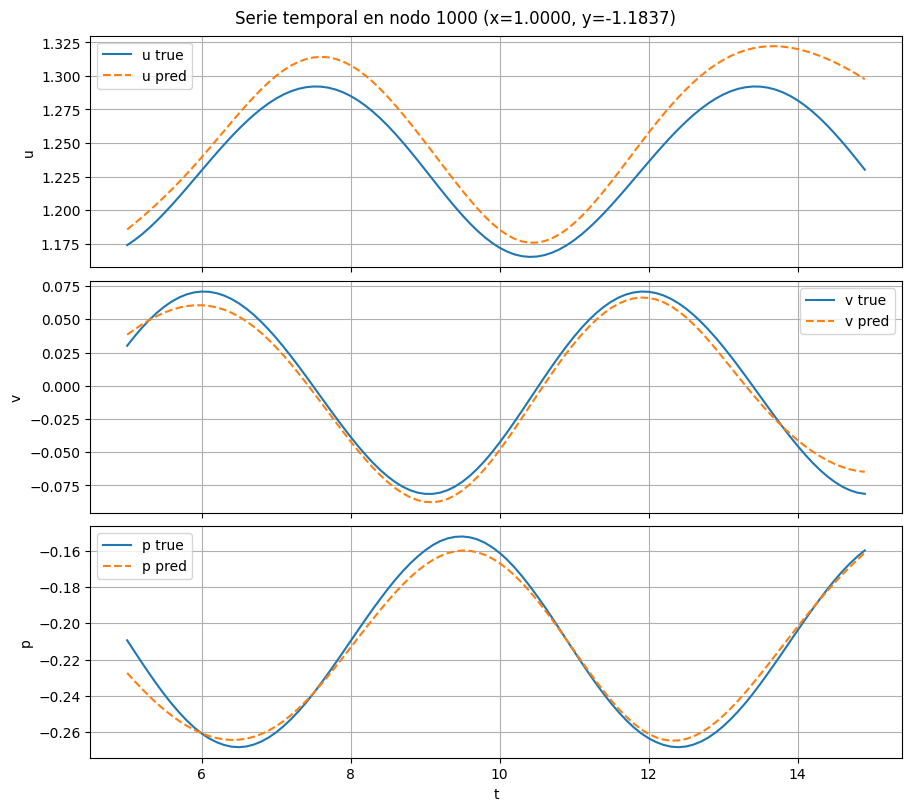

In [42]:
def plot_timeseries_at_point(model, Xtensor, Utensor_true, node_idx=None, xy=None, device=None):

    def _vec1d(x):
        if torch.is_tensor(x):
            x = x.detach().cpu().numpy()
        x = np.asarray(x)
        if x.ndim >= 2 and x.shape[-1] == 1:
            x = np.squeeze(x, axis=-1)
        return x.ravel()

    assert Xtensor.dim() == 3 and Xtensor.shape[-1] == 3, f"Xtensor debe ser [T,N,3], recibido {tuple(Xtensor.shape)}"
    assert Utensor_true.shape == Xtensor.shape, "Xtensor y Utensor_true deben tener el mismo shape [T,N,3]"

    T, N, _ = Xtensor.shape
    if device is None:
        device = Xtensor.device

    # Elegir nodo
    if xy is not None:
        x0, y0 = float(xy[0]), float(xy[1])
        XY0 = Xtensor[0, :, :2].detach().cpu().numpy()
        d2 = (XY0[:, 0]-x0)**2 + (XY0[:, 1]-y0)**2
        node_idx = int(np.argmin(d2))
        print(f"[INFO] Nodo más cercano a ({x0:.4f}, {y0:.4f}) → idx={node_idx} (dist={np.sqrt(d2[node_idx]):.3e})")
    else:
        node_idx = 0 if node_idx is None else int(node_idx)
        assert 0 <= node_idx < N, f"node_idx fuera de rango [0,{N-1}]"

    # Trayectoria temporal en ese nodo: (T,3)
    X_point = Xtensor[:, node_idx, :].to(device)
    # ¡Importante!: leaf + grad para poder derivar ψ wrt X
    X_point = X_point.detach().clone().requires_grad_(True)

    # Predicción con derivadas (NO usar torch.no_grad())
    # ---- Predicción ----
    u_pred_t = model.NN_u(X_point)
    v_pred_t = model.NN_v(X_point)
    p_pred_t = model.NN_p(X_point)

    # ---- A numpy 1D ----
    u_pred = _vec1d(u_pred_t)
    v_pred = _vec1d(v_pred_t)
    p_pred = _vec1d(p_pred_t)

    # Verdaderos
    U_true_point = Utensor_true[:, node_idx, :]               # (T,3)
    u_true = _vec1d(U_true_point[:, 0:1])
    v_true = _vec1d(U_true_point[:, 1:2])
    p_true = _vec1d(U_true_point[:, 2:3])

    # Tiempo
    t_series = _vec1d(X_point[:, 2])

    # Alinear longitudes
    L = min(len(t_series), len(u_pred), len(v_pred), len(p_pred),
            len(u_true), len(v_true), len(p_true))
    t_series = t_series[:L]
    u_pred, v_pred, p_pred = u_pred[:L], v_pred[:L], p_pred[:L]
    u_true, v_true, p_true = u_true[:L], v_true[:L], p_true[:L]

    # Métricas
    eps = 1e-12
    rmse_u = np.sqrt(np.mean((u_pred - u_true)**2))
    rmse_v = np.sqrt(np.mean((v_pred - v_true)**2))
    rmse_p = np.sqrt(np.mean((p_pred - p_true)**2))
    rel_u = rmse_u / (np.mean(np.abs(u_true)) + eps)
    rel_v = rmse_v / (np.mean(np.abs(v_true)) + eps)
    rel_p = rmse_p / (np.mean(np.abs(p_true)) + eps)
    print(f"[Nodo {node_idx}] RMSE  u={rmse_u:.3e} (rel {rel_u:.2%}), "
          f"v={rmse_v:.3e} (rel {rel_v:.2%}), p={rmse_p:.3e} (rel {rel_p:.2%})")

    # Plot
    fig, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True, constrained_layout=True)
    axs[0].plot(t_series, u_true, label='u true'); axs[0].plot(t_series, u_pred, '--', label='u pred')
    axs[0].set_ylabel('u'); axs[0].legend(); axs[0].grid(True)
    axs[1].plot(t_series, v_true, label='v true'); axs[1].plot(t_series, v_pred, '--', label='v pred')
    axs[1].set_ylabel('v'); axs[1].legend(); axs[1].grid(True)
    axs[2].plot(t_series, p_true, label='p true'); axs[2].plot(t_series, p_pred, '--', label='p pred')
    axs[2].set_xlabel('t'); axs[2].set_ylabel('p'); axs[2].legend(); axs[2].grid(True)

    xy_node = Xtensor[0, node_idx, :2].detach().cpu().numpy()
    fig.suptitle(f"Serie temporal en nodo {node_idx} (x={xy_node[0]:.4f}, y={xy_node[1]:.4f})")
    plt.show()

node_idx = 1000
plot_timeseries_at_point(model, Xtensor, Utensor, node_idx=node_idx, device=device)

Listo: guardado 'export/prediction_inverse031025.mat' con u_pred, v_pred, p_pred, x, y, t y los historiales.


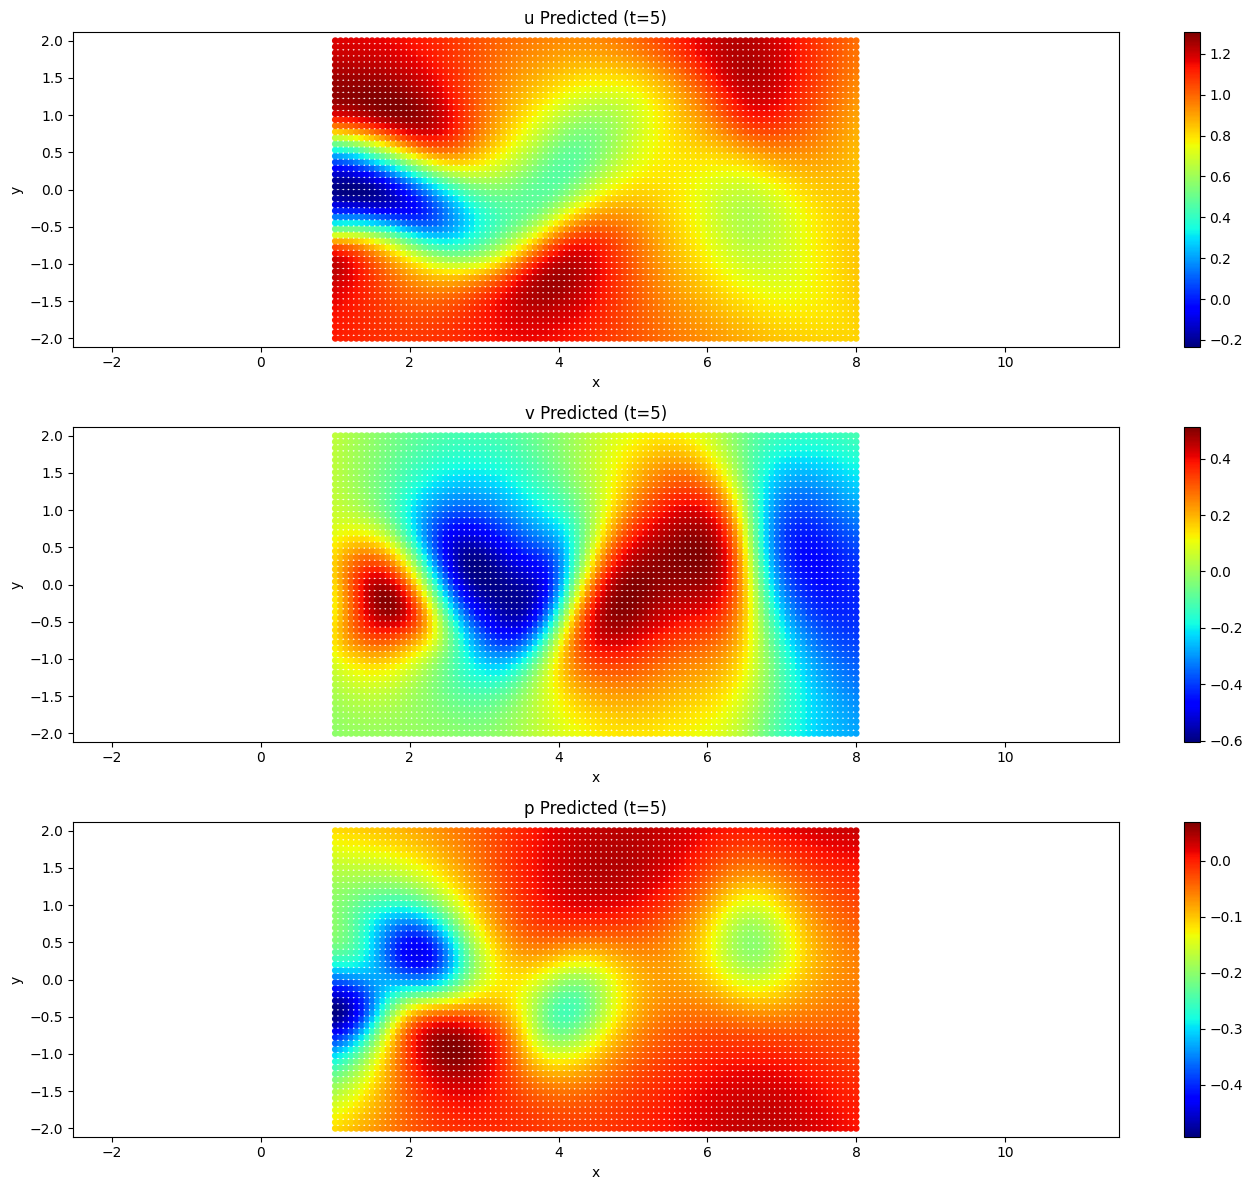

In [43]:
# --- Config ---
batch_size = 65536  # ajusta según tu GPU/CPU
model.eval()

# Xtensor esperado (T, N, D)
X_cpu = Xtensor.detach().cpu() if torch.is_tensor(Xtensor) else torch.from_numpy(np.asarray(Xtensor))
T, N, D = X_cpu.shape
X_flat = X_cpu.reshape(-1, D).to(device)

# buffers de salida (aplanados)
out_u = np.empty((T * N,), dtype=np.float32)
out_v = np.empty((T * N,), dtype=np.float32)
out_p = np.empty((T * N,), dtype=np.float32)  # asumimos que siempre hay p en tu modelo

# --- Predicción por batches usando 3 redes independientes ---
with torch.no_grad():
    for i in range(0, T * N, batch_size):
        xb = X_flat[i:i + batch_size]  # (B, D)

        # Tres redes independientes: cada una devuelve (B,1)
        up = model.NN_u(xb)
        vp = model.NN_v(xb)
        pp = model.NN_p(xb)

        # a numpy
        up = up.detach().cpu().numpy().squeeze(-1)
        vp = vp.detach().cpu().numpy().squeeze(-1)
        pp = pp.detach().cpu().numpy().squeeze(-1)

        # guardar en buffers
        out_u[i:i + len(up)] = up
        out_v[i:i + len(vp)] = vp
        out_p[i:i + len(pp)] = pp

        # limpieza opcional (sobre todo si usás GPU)
        del xb, up, vp, pp
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            torch.mps.empty_cache()

# reshape final a (T, N)
u_pred = out_u.reshape(T, N)
v_pred = out_v.reshape(T, N)
p_pred = out_p.reshape(T, N)

# --- Guardado ---
from scipy.io import savemat
import os

X_np = X_cpu.numpy()
x = X_np[..., 0]
y = X_np[..., 1]
t = X_np[..., 2] if D >= 3 else np.tile(np.arange(T, dtype=np.float32)[:, None], (1, N))

mdict = {
    "u_pred": u_pred, "v_pred": v_pred, "p_pred": p_pred,
    "x": x, "y": y, "t": t,
    # (Opcional) historiales
    "loss_total":     np.asarray(model.loss_history.get("Total",   []), dtype=np.float32),
    "loss_data":      np.asarray(model.loss_history.get("Data",    []), dtype=np.float32),
    "loss_physics":   np.asarray(model.loss_history.get("Physics", []), dtype=np.float32),
    "lambda_hist":    np.asarray(model.loss_history.get("Lambda",  []), dtype=np.float32),
    "lambda_Re_hist": np.asarray(model.loss_history.get("Reynold", []), dtype=np.float32),
}

os.makedirs("export", exist_ok=True)
savemat(os.path.join("export", "prediction_inverse031025.mat"), mdict, do_compression=True)

print("Listo: guardado 'export/prediction_inverse031025.mat' con u_pred, v_pred, p_pred, x, y, t y los historiales.")

# --- Visualización: selecciona el frame/tiempo k ---
k = 5  # el paso temporal que quieras

x_k = X_cpu[k, :, 0].numpy().ravel()
y_k = X_cpu[k, :, 1].numpy().ravel()

u_k = np.asarray(u_pred[k]).ravel()
v_k = np.asarray(v_pred[k]).ravel()
p_k = np.asarray(p_pred[k]).ravel()

fig, axs = plt.subplots(3, 1, figsize=(14, 12))

sc = axs[0].scatter(x_k, y_k, c=u_k, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[0]); axs[0].set_title(f'u Predicted (t={k})')

sc = axs[1].scatter(x_k, y_k, c=v_k, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[1]); axs[1].set_title(f'v Predicted (t={k})')

sc = axs[2].scatter(x_k, y_k, c=p_k, cmap='jet', s=15)
plt.colorbar(sc, ax=axs[2]); axs[2].set_title(f'p Predicted (t={k})')

for ax in axs:
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.axis('equal')
plt.tight_layout(); plt.show()